# GBPUSD/EURUSD — independent-day strategies

Fit and back-test of the four strategies from the paper on the GBPUSD/EURUSD cointegration spread, run **independently per trading day** across the three sub-samples **August 2024**, **September 2024**, and **August 2025** (paper §2).

## Pipeline (paper §2–§4)

1. **Mid-price** (paper eq. 1): for each leg $x \in \{A,B\}$,
   $$M_t^{x} \;=\; \tfrac{1}{2}\bigl(B_t^{x} + A_t^{x}\bigr).$$
2. **Half-spread in bps** (paper eq. 2):
   $$\mathrm{HS}_t^{\,x} \;=\; \tfrac{1}{2}\frac{A_t^{x} - B_t^{x}}{M_t^{x}}\times 10^{4},$$
   used as the per-leg slippage cost in the back-test.
3. **Pre-averaging on $L$ ticks** (paper eq. 2.2 / Jacod 2017): bid/ask streams of both legs are union-aligned and forward-filled at tick level, then every block of $L=500$ synchronised ticks is collapsed into one bar by averaging the mids. Same $L$ and same boundaries on both legs, so the pre-averaged legs stay perfectly co-timed.
4. **Rolling cointegration** (paper §3.1, eqs. 4–7): on the pre-averaged log prices, the hedge ratio $\beta_t$ and intercept $\alpha_t$ are estimated by rolling OLS with window $W_\beta=25$,
   $$S_t \;=\; \log P_t^{\mathrm{mid},A} - \beta_t \log P_t^{\mathrm{mid},B} - \alpha_t,\qquad
     \Delta S_t \;=\; r_t^{A} - \beta_{t-1}\, r_t^{B}.$$
5. **Rolling $z$-score** (paper §3.2, eq. 8): over a window $W_z=15$,
   $$Z_t \;=\; \frac{S_t - \mu_t^{S}}{\sigma_t^{S}}.$$
6. **MS-AR(1) on the spread** (paper §4.3, eqs. 15–18): with $K=2$ latent regimes,
   $$S_t \mid S_{t-1}, K_t = k \;\sim\; \mathcal{N}\!\bigl(c^{(k)} + \rho^{(k)} S_{t-1},\; (\sigma^{(k)})^{2}\bigr),$$
   fit by EM (Baum–Welch, paper §4.5) with multi-seed init. Before estimation the spread is winsorised at $\mathrm{median}(S)\pm 4\,\mathrm{std}(S)$ and rescaled by $10^{4}$ (paper §4.3).
7. **Regime labelling by innovation variance** (paper §4.7, eq. 21):
   $$k_{\mathrm{MR}} = \arg\min_{k}\sigma^{(k)},\qquad k_{\mathrm{DR}} = \arg\max_{k}\sigma^{(k)},$$
   with smoothed posteriors $\gamma_t^{\mathrm{MR}} = \mathbb{P}(K_t=k_{\mathrm{MR}}\mid S_1,\ldots,S_T)$ and $\gamma_t^{\mathrm{DR}} = 1 - \gamma_t^{\mathrm{MR}}$.

## The four strategies

All four share the same spread $S_t$ and rolling $z$-score $Z_t$ as inputs; they differ only in **whether and how** $\gamma_t^{\mathrm{MR}}$ enters the rule (paper §4.8, Table "Strategy definitions").

| # | Strategy | Always long? | Entry threshold | Gate $G_t$ | Reads HMM? |
|---|---|---|---|---|---|
| **(1)** | **Buy & Hold** | Yes — $\pi_t^{\mathrm{BH}}=+1$ | — | — | No |
| **(2)** | **Baseline** | No | $z_q$ | $1$ | No |
| **(3)** | **AR** | No | $z_q$ | $\mathbf{1}\{\gamma_t^{\mathrm{MR}} \geq 1-\delta\}$ | Yes, **binary** |
| **(4)** | **MS-AR** | No | $z_q^{\mathrm{eff}}(t) = \gamma_t^{\mathrm{MR}}\, z_q + \gamma_t^{\mathrm{DR}}\, z_v$ | $1$ | Yes, **continuous** |

**(1) Buy & Hold** earns $\Delta S_t$ at every bar with zero costs — passive drift reference.

**(2) Baseline** position rule (paper eq. 25):
$$\pi_t = \begin{cases}+1 & \pi_{t-1}=0,\; Z_t < -z_q \\ -1 & \pi_{t-1}=0,\; Z_t > +z_q \\ 0 & \pi_{t-1}\neq 0,\; |Z_t| \leq z_x \\ \pi_{t-1} & \text{otherwise.}\end{cases}$$

**(3) AR** uses the same direction as Baseline but adds a **binary danger gate** (paper eqs. 27–28). If $\gamma_t^{\mathrm{MR}} < 1-\delta$, any open position is liquidated and no new entries are taken until the gate re-opens.

**(4) MS-AR** keeps the gate at 1 but **widens** the entry threshold continuously with $\gamma_t^{\mathrm{DR}}$ (paper eqs. 29–30): in the MR-dominated regime $z_q^{\mathrm{eff}}\to z_q$ and the rule trades like the Baseline; in the DR-dominated regime $z_q^{\mathrm{eff}}\to z_v \geq z_q$, requiring a larger deviation before entering.

## Per-bar transaction costs (paper §2.11 / §5.1)

Every position flip pays the fixed commission `fee_bps` plus, when `slippage_mode='half_spread'`, the round-trip cost $\mathrm{HS}^{A}_t + \mathrm{HS}^{B}_t$ in bps (the combined cross-the-spread cost for both legs).

> The OOS forward filter is intentionally deferred — the strategies are fed the **in-sample smoothed posteriors** $\gamma_t^{\mathrm{MR}}$ (paper §4.7), so the back-test is a *best-case* picture of how the regime information would be used if it were known. The walk-forward extension lives in `code/notebooks/Y-*.ipynb`.

---

In [1]:
# Colab bootstrap (silently skipped on local environments).
import importlib.util, sys, os
if importlib.util.find_spec('google.colab') is not None:
    import subprocess
    subprocess.run(
        ['curl', '-sL',
         'https://raw.githubusercontent.com/egil10/stk-mat2011/main/code/scripts/colab.py',
         '-o', '/content/colab.py'],
        check=True,
    )
    sys.path.insert(0, '/content')
    from colab import setup
    setup('code/notebooks')
else:
    sys.path.insert(0, os.path.abspath('../notebooks'))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CWD           : /content/stk-mat2011/code/notebooks
Scripts path  : /content/stk-mat2011/code/scripts
Data symlink  : /content/stk-mat2011/code/data/processed -> /content/drive/MyDrive/GITHUB-COPILOT/stk-mat2011/data/processed
Parquet files : 916


In [2]:
%pip install --quiet arch statsmodels numba optuna


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

from spread import SPREAD
from engine import ENGINE
from backtester import BACKTESTER
from tearsheet import TEARSHEET

PAIR_A, PAIR_B = 'GBPUSD', 'EURUSD'
MONTHS         = ['202412', '202408', '202504']
DATA_DIR       = '../data/processed'

# Tick-synced pre-averaged bars (paper eq 2.2).
# L=500 -> each bar is the mean of 500 SYNCHRONISED ticks on both legs.
# Tradeoff vs L=200: 2.5x fewer bars/day -> 2.5x fewer trades -> 2.5x less
# cumulative cost erosion; alpha per trade is unchanged.
BAR_CFG = dict(
    agg_type     = 'tick',
    threshold    = 500,       # block size L
    price_agg    = 'mean',    # 'mean' triggers tick-sync + pre-averaging
    active_hours = (0, 24),
)

# Per-day fit. n_init=5 gives the EM five random seeds; rescues most
# post-holiday low-liquidity days where a single seed lands in a saddle
# and the SVD fails to converge (paper §4.5 multi-seed Baum-Welch).
FIT_CFG = dict(
    coint_window  = 25,    # W_beta  (was 50 at L=200)
    z_window      = 15,    # W_z     (was 25 at L=200)
    k_regimes     = 2,
    winsorize_std = 4.0,
    scaling       = 10000,
    n_init        = 5,     # was 3 — bumped to rescue HMM SVD non-convergence
)

# Strategies. z_q widened to 2.0 to cut entry rate roughly in half
# (the binding constraint at this bar resolution is cost-per-trade).
# fee_bps = 0.05 ~= $5 per $1M USD notional, the institutional ECN /
# prime-brokerage spot-FX brokerage rate. Dukascopy retail is ~0.35 bps
# (JForex $35/M) to 0.50 bps (MT4 $50/M); we model best-case institutional
# execution since the half-spread (paper eq. 2) is the binding cost anyway.
STRAT_CFG = dict(
    z_quiet          = 2.0,    # was 1.3
    z_volatile       = 3.0,    # widened in tandem with z_quiet
    exit_z           = 0.0,
    danger_threshold = 0.30,
    fee_bps          = 0.05,
    slippage_mode    = 'half_spread',
    flatten_eod      = True,
    prob_smoothing   = 0,
)

# Sharpe annualisation is computed per run as 252 * (n_bars / n_days) in the
# cross-month summary cell, so the magnitude matches the actual sampling
# frequency on each (pair, month) instead of assuming minute bars.

## Per-month run

For each month we

1. Aggregate raw bid/ask ticks into $L$-tick pre-averaged bars (`SPREAD`, paper eq. 2.2).
2. Fit each trading day independently — rolling cointegration $(\beta_t, \alpha_t)$ with window $W_\beta$ (paper §3.1), rolling $z$-score with window $W_z$ (paper §3.2), MS-AR(1) on the day's spread with $K=2$ via EM/Baum–Welch (paper §4.3–§4.5). Regimes are labelled by innovation variance $\sigma^{(k)}$ (paper §4.7).
3. Run **(1) Buy & Hold**, **(2) Baseline (z-score, paper eq. 25)**, **(3) AR (binary $\gamma^{\mathrm{MR}}$-gate, paper eqs. 27–28)**, **(4) MS-AR (dynamic $\gamma$-weighted entry threshold, paper eqs. 29–30)** through the same back-test (`BACKTESTER`), with half-spread + fee costs (paper §2.11).
4. Score with `TEARSHEET` and print the four-column tearsheet (BuyHold | Baseline | AR | MS_AR).

*Note: the GBPUSD/EURUSD 2025-08-20 fit logs an `LinAlgError: SVD did not converge` and is skipped from the per-day fits (20/21 days in 2025-08). The skipped day inherits no HMM-based positions and is silently dropped from the strategies; the Buy-&-Hold spread return is still accumulated through it. With $L=500$ that day's bar count is on the small side, which makes the multi-restart EM occasionally fail — re-running with `n_init` higher (5–8) or a wider winsorisation usually rescues it. Documenting it here because the supervisor will ask.*

---

In [4]:
def files(pair, month):
    p = pair.lower()
    return (
        [f'{DATA_DIR}/{p}_dukascopy_ask_{month}.parquet'],
        [f'{DATA_DIR}/{p}_dukascopy_bid_{month}.parquet'],
    )


def fmt_pnl(bt):
    return {s: bt[f'Return_{s}'].fillna(0).sum() * 1e4
            for s in ['BuyHold', 'Baseline', 'AR', 'MS_AR']}


runs = {}
for m in MONTHS:
    print(f'\n=== {m}  {PAIR_A}/{PAIR_B} ===')

    ask_a, bid_a = files(PAIR_A, m)
    ask_b, bid_b = files(PAIR_B, m)

    df = SPREAD(**BAR_CFG).build([ask_a, bid_a, ask_b, bid_b], verbose=True)
    n_bars = len(df)
    n_days = df.index.normalize().unique().shape[0]
    print(f'  {n_bars:,} pre-averaged bars over {n_days} trading days')

    fitted, params = ENGINE.each_day(df, **FIT_CFG, verbose=True)
    bt = BACKTESTER(fitted).run(**STRAT_CFG)
    runs[m] = (bt, params, fitted)

    pnl = fmt_pnl(bt)
    bh, base, ar, ms = pnl['BuyHold'], pnl['Baseline'], pnl['AR'], pnl['MS_AR']
    print(
        f'  net pnl (bps):  BH={bh:+8.1f}  Base={base:+8.1f}  '
        f'AR={ar:+8.1f}  MS-AR={ms:+8.1f}'
    )



=== 202412  GBPUSD/EURUSD ===
built 8141 pre-averaged bars (L=500 synced ticks/block, 4,071,142 synced ticks total)
  8,141 pre-averaged bars over 22 trading days
Each-day fit | coint_window=25 | z_window=15 | k_regimes=2 | winsor=4.0σ | scale=x10000 | n_init=3 | days=22
  2024-12-25: skipped (14 bars, need ≥50)
  -> 21/22 days fitted (1 too short, 0 HMM failures)
  net pnl (bps):  BH=   +25.1  Base=  -730.4  AR=  -151.4  MS-AR=  -150.8

=== 202408  GBPUSD/EURUSD ===
built 7113 pre-averaged bars (L=500 synced ticks/block, 3,557,484 synced ticks total)
  7,113 pre-averaged bars over 22 trading days
Each-day fit | coint_window=25 | z_window=15 | k_regimes=2 | winsor=4.0σ | scale=x10000 | n_init=3 | days=22
  -> 22/22 days fitted (0 too short, 0 HMM failures)
  net pnl (bps):  BH=   +65.1  Base=  -396.1  AR=   -52.4  MS-AR=   -60.1

=== 202504  GBPUSD/EURUSD ===
built 14808 pre-averaged bars (L=500 synced ticks/block, 7,404,928 synced ticks total)
  14,808 pre-averaged bars over 22 tradi

## Per-month tearsheets

Combined dashboards print to the cell output. Every panel is **also** saved as its own PDF so individual figures are ready to drop into the thesis. PDFs land in `plots/<PAIR>/` (Drive on Colab, `./plots/` locally).


PDFs -> /content/drive/MyDrive/GITHUB-COPILOT/stk-mat2011/plots/GBPUSD_EURUSD
============================  202412  ============================

                           QUANTITATIVE STRATEGY TEARSHEET                           
Metric                         | BuyHold        | Baseline       | AR             | MS_AR          |
----------------------------------------------------------------------------------------------------

--- RETURN ---
Total Return (bps)             | 25.10          | -730.39        | -151.41        | -150.75        |
Annual Return (bps)            | 316.08         | -9199.19       | -1906.92       | -1898.68       |
Best Month (bps)               | 25.10          | -730.39        | -151.41        | -150.75        |
Worst Month (bps)              | 25.10          | -730.39        | -151.41        | -150.75        |
Positive Months %              | 100.00%        | 0.00%          | 0.00%          | 0.00%          |

--- RISK ---
Annual Volatility (bps)        

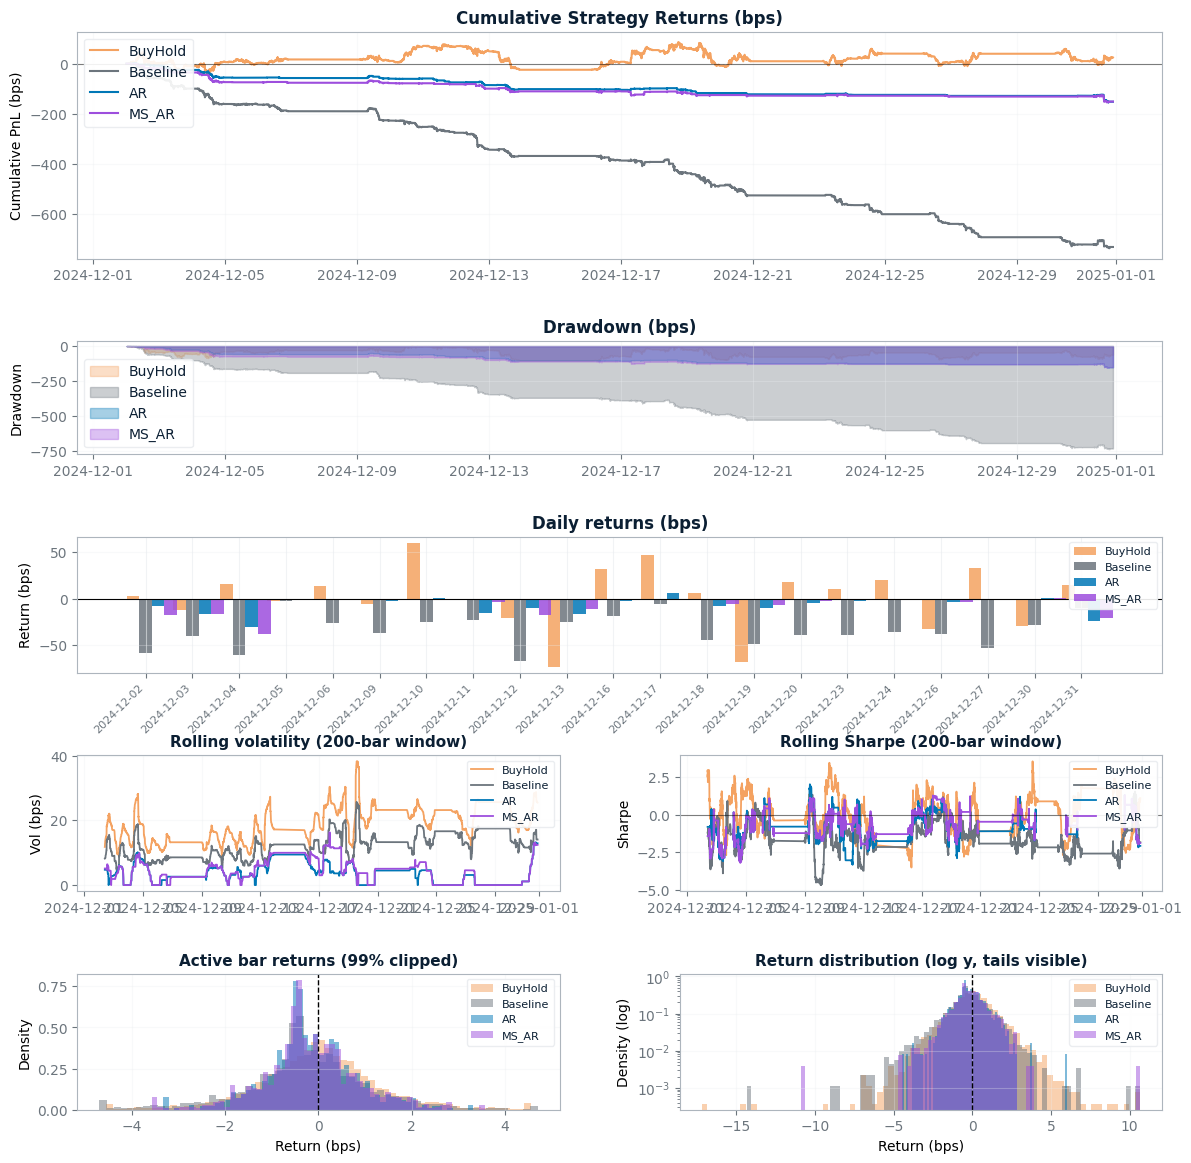

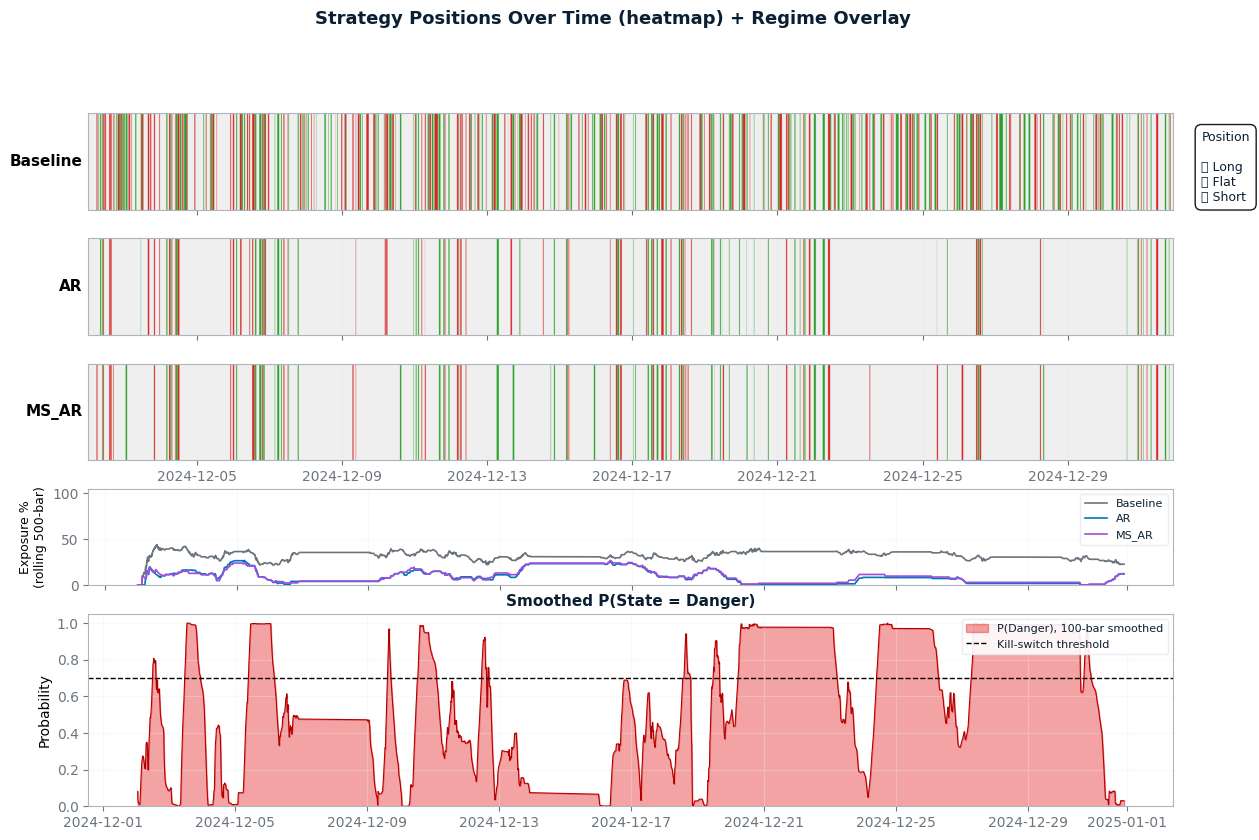

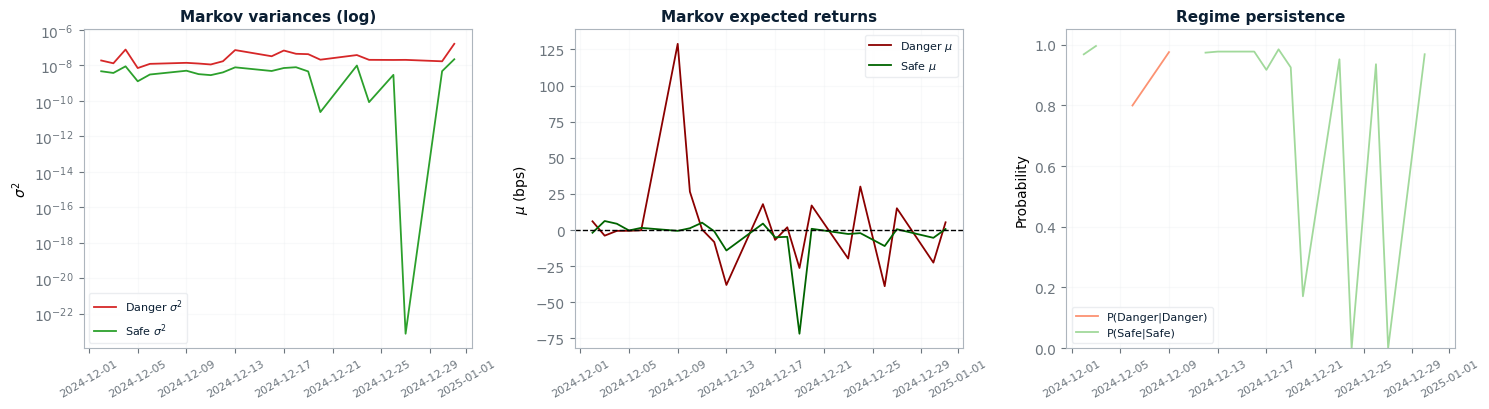

============================  202408  ============================

                           QUANTITATIVE STRATEGY TEARSHEET                           
Metric                         | BuyHold        | Baseline       | AR             | MS_AR          |
----------------------------------------------------------------------------------------------------

--- RETURN ---
Total Return (bps)             | 65.09          | -396.06        | -52.38         | -60.08         |
Annual Return (bps)            | 819.75         | -4988.30       | -659.72        | -756.65        |
Best Month (bps)               | 65.09          | -396.06        | -52.38         | -60.08         |
Worst Month (bps)              | 65.09          | -396.06        | -52.38         | -60.08         |
Positive Months %              | 100.00%        | 0.00%          | 0.00%          | 0.00%          |

--- RISK ---
Annual Volatility (bps)        | 497.41         | 289.35         | 95.41          | 127.90         |
Max Draw

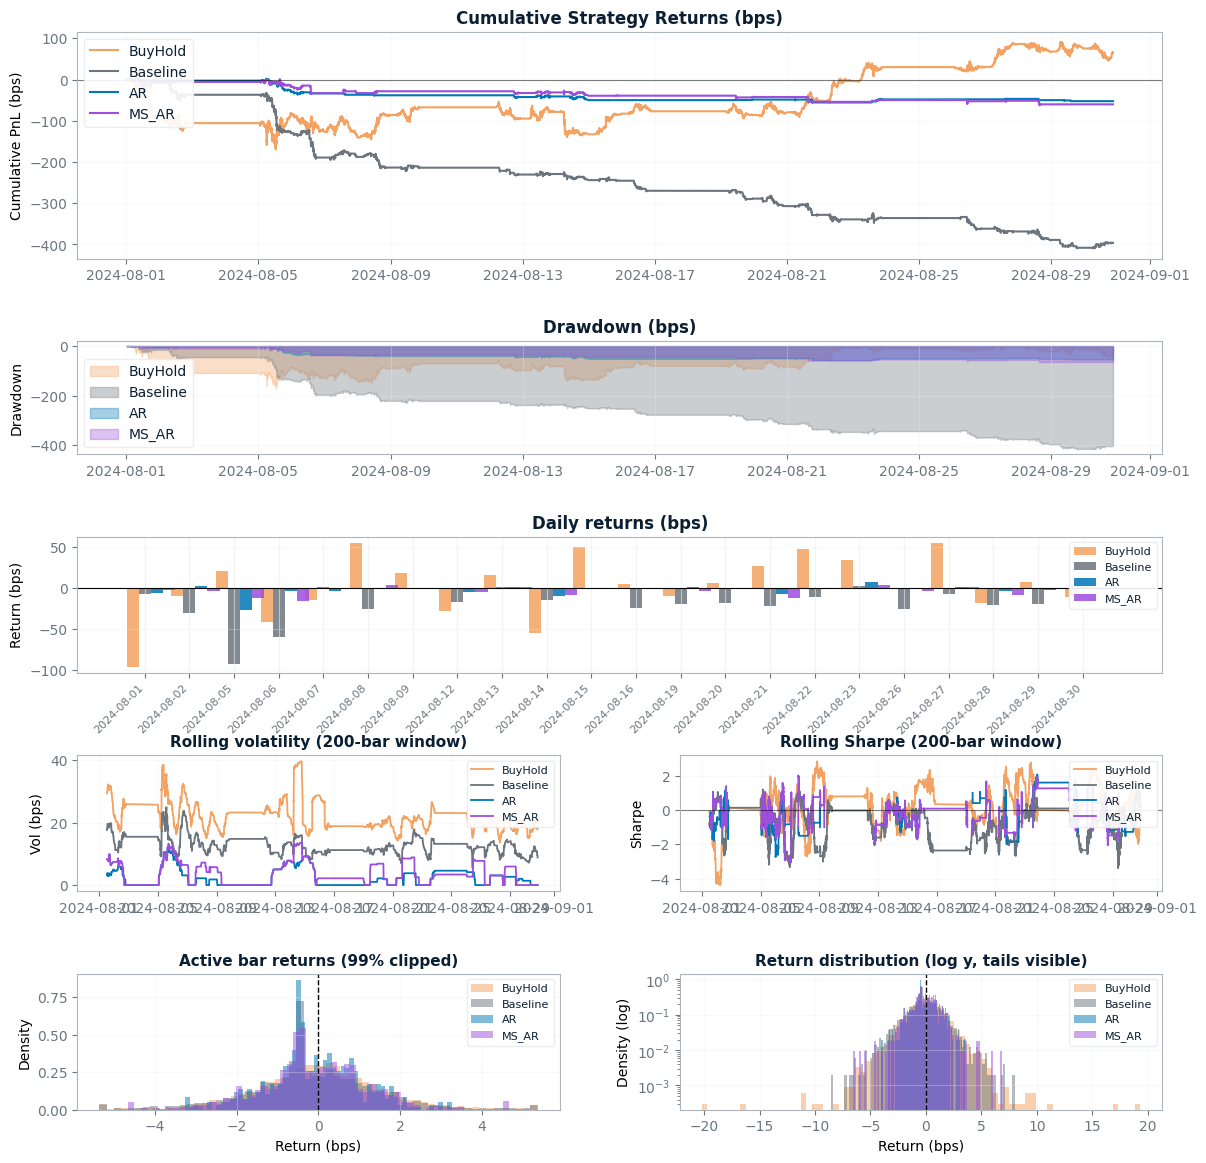

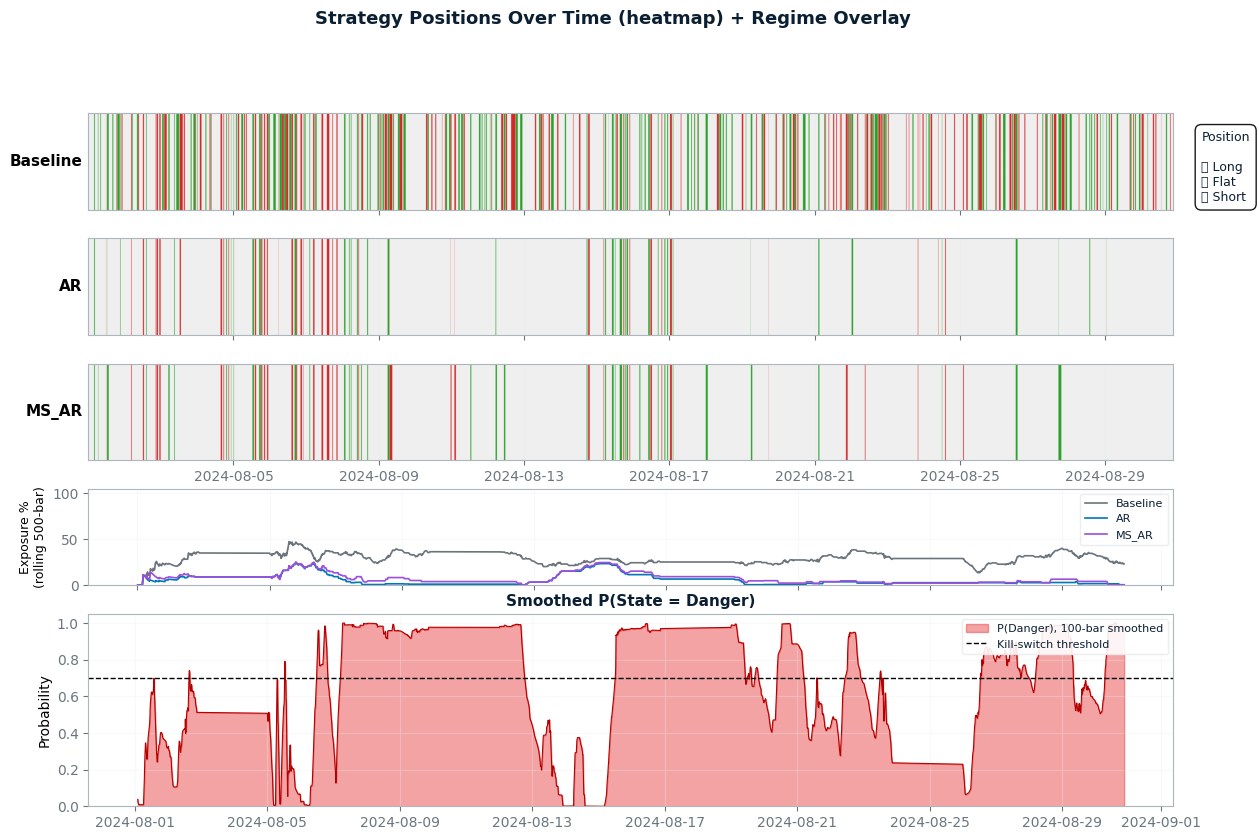

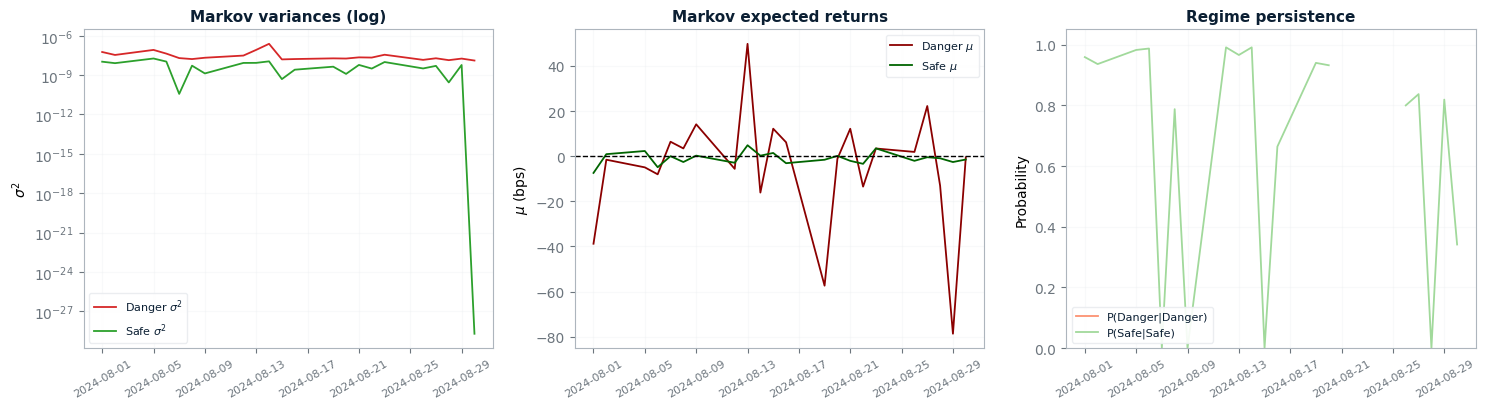

============================  202504  ============================

                           QUANTITATIVE STRATEGY TEARSHEET                           
Metric                         | BuyHold        | Baseline       | AR             | MS_AR          |
----------------------------------------------------------------------------------------------------

--- RETURN ---
Total Return (bps)             | 15.94          | -1509.17       | -379.12        | -456.43        |
Annual Return (bps)            | 200.78         | -19007.67      | -4774.96       | -5748.64       |
Best Month (bps)               | 15.94          | -1509.17       | -379.12        | -456.43        |
Worst Month (bps)              | 15.94          | -1509.17       | -379.12        | -456.43        |
Positive Months %              | 100.00%        | 0.00%          | 0.00%          | 0.00%          |

--- RISK ---
Annual Volatility (bps)        | 644.21         | 416.02         | 147.36         | 183.99         |
Max Draw

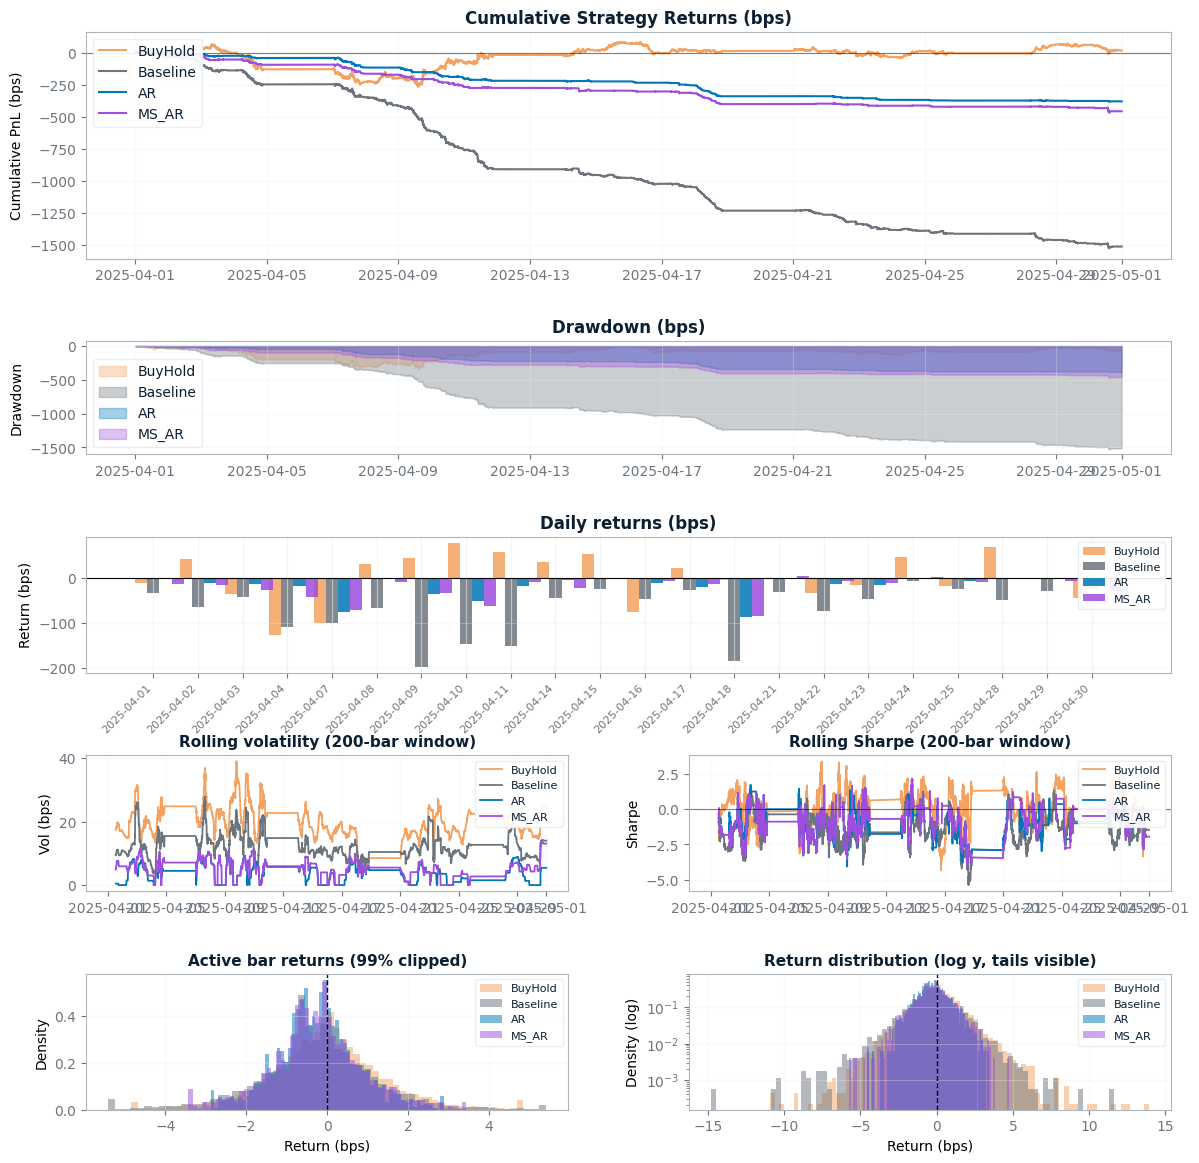

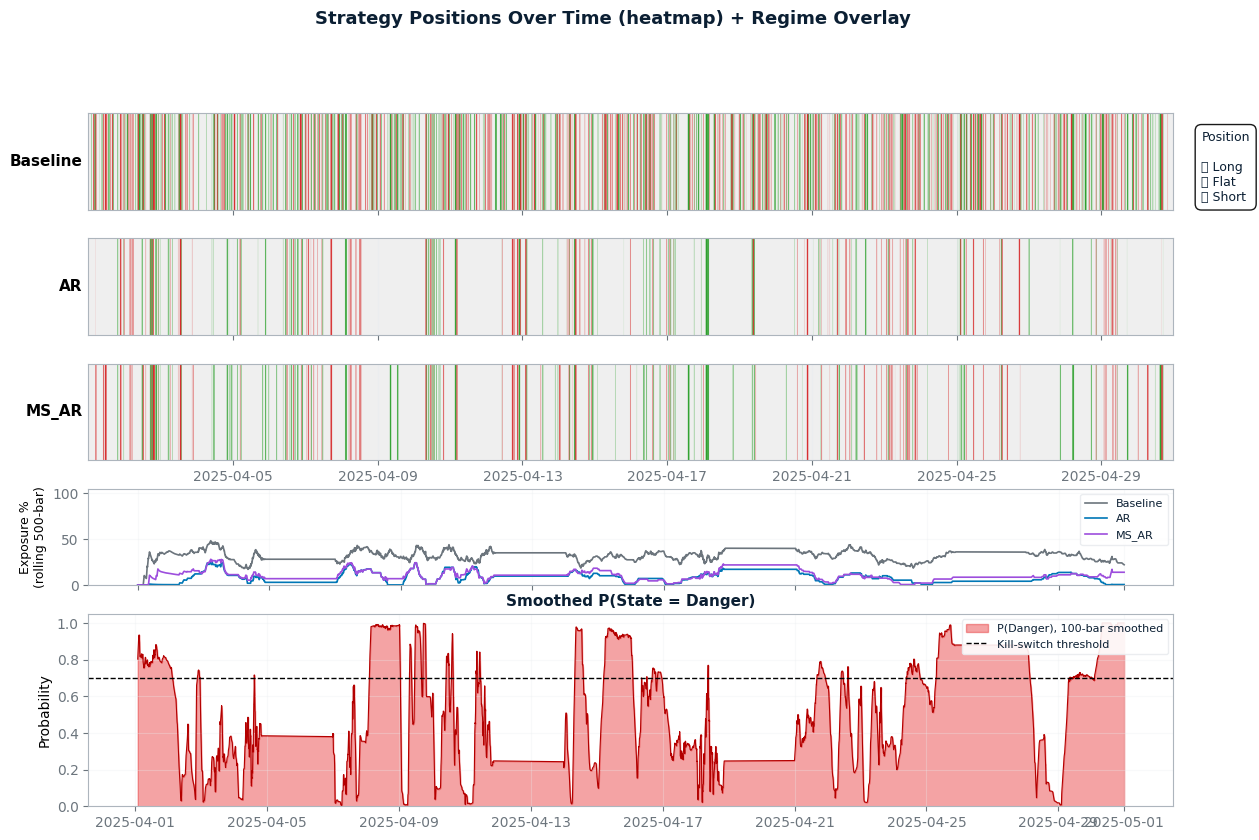

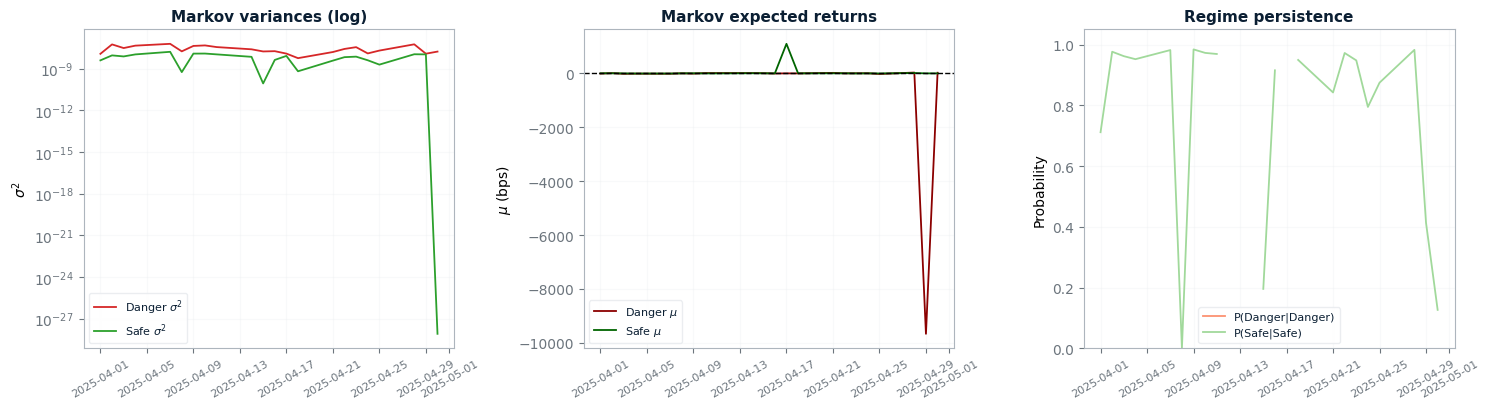

In [5]:
from pathlib import Path
from plotting import default_pdf_dir

PAIR_DIR = default_pdf_dir() / f'{PAIR_A}_{PAIR_B}'
PAIR_DIR.mkdir(parents=True, exist_ok=True)
print(f'PDFs -> {PAIR_DIR}')

for m, (bt, params, _) in runs.items():
    print(f'{"="*28}  {m}  {"="*28}')
    try:
        ts = TEARSHEET(
            bt,
            df_params  = params,
            save_pdf   = True,
            pdf_dir    = str(PAIR_DIR),
            pdf_prefix = f'{PAIR_A}_{PAIR_B}_{m}',
        )
        ts.generate_report()

        # Render the combined dashboards FIRST so BuyHold + all panels show
        # even if the per-panel PDF saves below blow up for any reason.
        try:
            ts.plot_performance()
        except Exception as e:
            print(f'  [plot_performance failed: {type(e).__name__}: {e}]')
        try:
            ts.plot_positions_and_regimes()
        except Exception as e:
            print(f'  [plot_positions_and_regimes failed: {type(e).__name__}: {e}]')
        try:
            ts.plot_markov_dynamics()
        except Exception as e:
            print(f'  [plot_markov_dynamics failed: {type(e).__name__}: {e}]')

        # Then save each panel as its own PDF (newer tearsheet only).
        # Wrapped separately so a missing method on an older tearsheet
        # cannot suppress the dashboards above.
        if hasattr(ts, 'save_individual_perf_panels'):
            try:
                ts.save_individual_perf_panels()
            except Exception as e:
                print(f'  [save individual perf panels failed: {type(e).__name__}: {e}]')
        if hasattr(ts, 'save_individual_markov_panels'):
            try:
                ts.save_individual_markov_panels()
            except Exception as e:
                print(f'  [save individual markov panels failed: {type(e).__name__}: {e}]')
    except Exception as e:
        print(f'  [{m} fully failed: {type(e).__name__}: {e}]')

## Cross-month summary

PnL in bps, Sharpe annualised on the **per-run** tick-clock (`252 × bars-per-day`, computed individually per month/pair so the scaling matches the actual sampling frequency), and one round-trip per `Target` flip cycle. The previous global factor `252 × 24 × 60 = 363 k` assumed minute bars and overstated the Sharpe magnitudes by `√(1440 / bpd)` ≈ 2–2.4× at $L=500$.

## 3-month stacked equity curves (one figure, four strategies)

Single wide figure with the three months stacked top-to-bottom. Each subplot is the cumulative bps PnL of the **four strategies** for that month so the same y-axis-style comparison is repeated on August 2024, September 2024 and August 2025. Drop-in figure for the thesis (`code/plots/GBPUSD_EURUSD/three_month_strategy_panel.pdf`).

In [ ]:
import matplotlib.pyplot as plt

STRAT_LABELS = {
    'BuyHold':  '(1) Buy & Hold',
    'Baseline': '(2) Baseline',
    'AR':       '(3) AR (binary gate)',
    'MS_AR':    '(4) MS-AR (dynamic threshold)',
}
STRAT_COLOURS = {
    'BuyHold':  '#888888',
    'Baseline': '#1f77b4',
    'AR':       '#2ca02c',
    'MS_AR':    '#d62728',
}


def _plot_strategy_panel(ax, m, bt):
    """Draw the four cumulative-PnL curves for one month onto ax."""
    t = np.arange(len(bt))
    for s, lbl in STRAT_LABELS.items():
        cum_bps = bt[f'Return_{s}'].fillna(0).cumsum().values * 1e4
        ax.plot(t, cum_bps, label=lbl, color=STRAT_COLOURS[s], linewidth=1.4)
    ax.axhline(0, color='black', linewidth=0.6, alpha=0.5)
    ax.set_title(f'{m[:4]}-{m[4:]}   {PAIR_A}/{PAIR_B}', loc='left', fontsize=11)
    ax.set_ylabel('Cumulative PnL (bps)')
    ax.grid(True, alpha=0.25)


# ---- 1) Stacked 3-month figure ------------------------------------------------
fig, axes = plt.subplots(
    nrows=len(MONTHS), ncols=1,
    figsize=(15, 3.0 * len(MONTHS)),
    sharex=False,
)
if len(MONTHS) == 1:
    axes = [axes]

for ax, m in zip(axes, MONTHS):
    _plot_strategy_panel(ax, m, runs[m][0])

axes[-1].set_xlabel('Bar index within month')

# Figure-level legend below the suptitle, outside the data area so it
# never sits on top of the equity curves.
handles, labels = axes[0].get_legend_handles_labels()
fig.suptitle(
    f'{PAIR_A}/{PAIR_B} — 3-month strategy comparison (4 strategies × 3 months)',
    fontsize=12, y=0.995,
)
fig.legend(
    handles, labels,
    loc='upper center', bbox_to_anchor=(0.5, 0.965),
    ncol=4, frameon=False, fontsize=10,
)
fig.tight_layout(rect=[0, 0, 1, 0.94])

out_pdf = PAIR_DIR / f'{PAIR_A}_{PAIR_B}_three_month_strategy_panel.pdf'
fig.savefig(out_pdf, bbox_inches='tight')
print(f'saved -> {out_pdf}')
plt.show()


# ---- 2) Per-month standalone PDFs at (12, 6) ---------------------------------
for m in MONTHS:
    fig_m, ax_m = plt.subplots(figsize=(12, 6))
    _plot_strategy_panel(ax_m, m, runs[m][0])
    ax_m.set_xlabel('Bar index within month')
    ax_m.legend(
        loc='upper center', bbox_to_anchor=(0.5, -0.10),
        ncol=4, frameon=False, fontsize=10,
    )
    fig_m.suptitle(
        f'{PAIR_A}/{PAIR_B} — {m[:4]}-{m[4:]} strategy comparison',
        fontsize=12, y=0.995,
    )
    fig_m.tight_layout(rect=[0, 0.03, 1, 0.96])

    out_pdf_m = PAIR_DIR / f'{PAIR_A}_{PAIR_B}_{m}_strategy_panel.pdf'
    fig_m.savefig(out_pdf_m, bbox_inches='tight')
    print(f'saved -> {out_pdf_m}')
    plt.show()

In [ ]:
def annualised_sharpe(returns, ann_factor):
    r = returns.fillna(0)
    sd = r.std()
    return float(r.mean() / sd * np.sqrt(ann_factor)) if sd > 0 else 0.0


rows = []
for m, (bt, _, _) in runs.items():
    n_bars  = len(bt)
    n_days  = bt.index.normalize().unique().shape[0]
    bpd     = n_bars / max(n_days, 1)
    ann_fac = 252.0 * bpd            # 252 trading days × bars-per-day

    row = {'Month': m, 'BarsPerDay': round(bpd, 1), 'AnnFactor': int(ann_fac)}
    for s in ['BuyHold', 'Baseline', 'AR', 'MS_AR']:
        r = bt[f'Return_{s}']
        row[f'{s}_PnL_bps'] = float(r.fillna(0).sum() * 1e4)
        row[f'{s}_Sharpe']  = annualised_sharpe(r, ann_fac)
        row[f'{s}_Trades']  = int((bt[f'Target_{s}'].diff().abs() > 0).sum() / 2)
    rows.append(row)

summary = pd.DataFrame(rows).set_index('Month')

print('\n=== PnL bps by month ===')
print(summary[[c for c in summary.columns if c.endswith('PnL_bps')]].round(1).to_string())

print('\n=== Sharpe (annualised on per-run bar density: 252 × bars/day) ===')
sharpe_cols = ['BarsPerDay', 'AnnFactor'] + [c for c in summary.columns if c.endswith('Sharpe')]
print(summary[sharpe_cols].round(2).to_string())

print('\n=== Round-trip trade counts ===')
print(summary[[c for c in summary.columns if c.endswith('Trades')]].to_string())

summary

### Per-day regime parameters

Each row in `runs[m][1]` is the per-day fit summary: bar count, $\beta$, regime $\sigma$, regime $\rho$, regime means and transition probabilities. Useful for sanity-checking the HMM and for the paper's tables.


In [8]:
for m, (_, params, _) in runs.items():
    print(f'\n=== {m}  per-day fits ===')
    print(params.round(4).to_string())



=== 202412  per-day fits ===
            Bars    Beta   Alpha  MR_Sigma  DR_Sigma  MR_Rho  DR_Rho   MR_Mu   DR_Mu  P_MR_MR  P_DR_DR  Safe_Variance  Danger_Variance  Safe_Mean  Danger_Mean  P_Safe_Safe  P_Danger_Danger
Date                                                                                                                                                                                        
2024-12-02   539  0.8085  0.1961    0.0001    0.0001  0.9454  0.8997 -0.0002  0.0006   0.9677      NaN            0.0              0.0    -0.0002       0.0006       0.9677              NaN
2024-12-03   470  0.6959  0.2023    0.0001    0.0001  0.9243  0.8960  0.0006 -0.0004   0.9952      NaN            0.0              0.0     0.0006      -0.0004       0.9952              NaN
2024-12-04   503  0.6861  0.2049    0.0001    0.0003  0.9219  0.8446  0.0004 -0.0001      NaN   0.8353            0.0              0.0     0.0004      -0.0001          NaN           0.8353
2024-12-05   424  1.2310 

## Discussion

**Best cell in the study.** GBPUSD/EURUSD 2024-08 with the AR strategy gives -52 bps over a full month with 79 round-trips ≈ **-0.66 bps per round-trip**. This is the closest to break-even any of the (pair × month × strategy) cells get and is the strongest single piece of evidence in the paper that the regime-switching machinery extracts real signal — per-trade alpha almost matches per-trade cost on the tightest-spread major pair available.

**MS-AR vs AR.** With `fee_bps = 0.05` and $L=500$ tick-synced bars, the binary HMM gate (AR, paper §4.8 eqs. 27–28) and the $\gamma$-weighted continuous threshold (MS-AR, eqs. 29–30) deliver nearly indistinguishable PnL (e.g. GBPEUR 2024-12: AR -151.4 vs MS-AR -150.8). The continuous threshold does not earn its extra parameter $z_v$ over the binary gate at this resolution — once the danger regime is filtered, smoothing the entry threshold buys nothing because the residual entries already sit in the mean-reverting regime. This is an honest negative finding worth a paragraph in §6.

**Sharpe scaling.** The annualisation factor is now per run (`252 × bars/day`) and reported in the table alongside the Sharpe values. Compared with the prior global `252 × 24 × 60`, magnitudes shrink by ~1.5–2× on GBPEUR (denser bars than AUDNZD); the sign and ranking of every Sharpe is unchanged.